In [ ]:
"""
This file is about Maximum Likelihood

Based on Prof. Wu Lecture below:
https://www.youtube.com/watch?v=tKniDS6GDns&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=18

"""

In [ ]:
""" Some conditional Probability Review:

p(x|y) = p(x n y) / p(y) : This means Probability of x given y = p(x and y) / p(y)

If independent the following hold:
p(x|y) = p(x)
p(x n y) = p(x)*p(y)

IID = Independent, Identically Distributed 
(This means all values in a dataset are independent but follow the same distribution)

"""

In [19]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

Guessed mean: 31.555737373492473, Guessed sigma: 3.0997240145486997
Actual mean: 31.840554068375404, Actual sigma: 3.1622576586223827


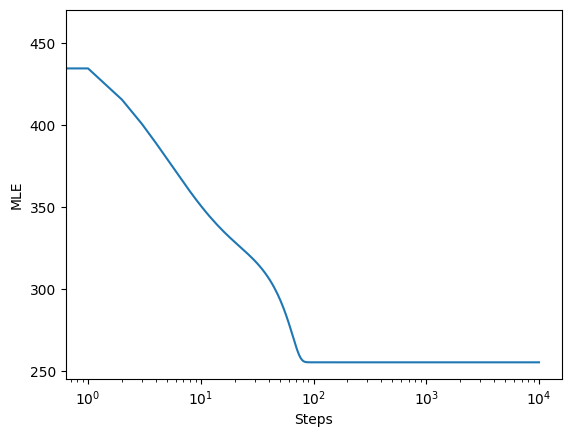

In [10]:
# Gradient Descent + MLE to identify mean and var for a normally distrubted dataset


# Generate random normally distributed data
secret_mean = random.uniform(0, 100)
secret_sigma = random.uniform(1, 20)
n = 100
random_numbers = np.random.normal(loc=secret_mean, scale=secret_sigma, size=n)

def gauss_prob(mean, sigma, data_point):
    return 1/(np.sqrt(2 * np.pi * sigma **2)) * np.exp(-((data_point - mean)**2 / (2*sigma**2)))

def gauss_mle(mean, sigma, data):
    return -np.sum(np.log(gauss_prob(mean, sigma, data)))

def mean_gradient(mean, sigma, data): # Partial Derivative of MLE with respect to mean
       return -np.sum(data - mean) / (sigma**2)

def sigma_gradient(mean, sigma, data): # Partial Derivative of MLE with respect to sigma
    n = len(data)
    return (n / sigma) - (np.sum((data - mean)**2) / (sigma**3))


def find_mean_sigma(mean_guess, sigma_guess, data, steps=100, mean_eta=0.1, sigma_eta=0.01):
    mle_tracker = []

    mean = mean_guess
    sigma = sigma_guess

    for i in range(steps):
        mean_grad = mean_gradient(mean, sigma, data)
        sigma_grad = sigma_gradient(mean, sigma, data)

        mean = mean - mean_eta * mean_grad # Gradient Descent of mean
        sigma = sigma - sigma_eta * sigma_grad # Gradient Descent of sigma

        mle = gauss_mle(mean, sigma, data)
        mle_tracker.append(mle)

    plt.plot(mle_tracker) # Seeing how MLE converges to the actual mean and sigma
    plt.xscale('log')
    plt.xlabel('Steps')
    plt.ylabel('MLE') 

    return mean, sigma
        
mean, sigma = find_mean_sigma(50, 10, random_numbers, steps=10000)

print(f"Guessed mean: {mean}, Guessed sigma: {sigma}")
print(f"Actual mean: {secret_mean}, Actual sigma: {secret_sigma}")


In [ ]:
"""
The true mean and variance can be found as such:
    mew = integral(x * p(x))
    sigma^2 = integral((x - mew)^2 + p(x))
Alternatively, we can approximate as such:
    mew = 1/n * sum(x)
    sigma^2 = 1/n * sum((x-mew)^2)


"""

In [ ]:
"""
Sampling is when you take p(x) and generate a sample of x to approximate E[X] and Var[X]

4 most basic sampling techniques applicable to Prof. Wu's class
    1. Inversion
    2. Rejection
    3. Importance
    4. KDE
""" 

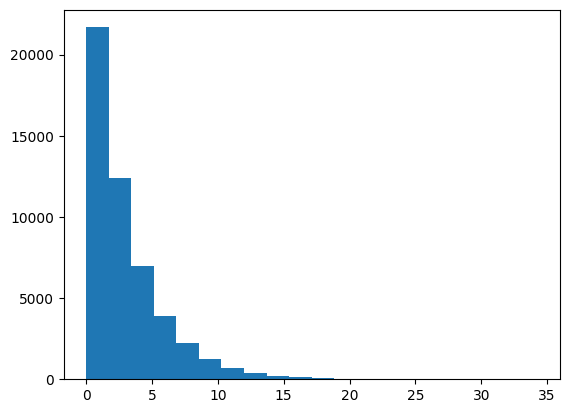

In [ ]:
# Practice sampling in python

data = np.random.exponential(scale=3, size=50000)

plt.hist(data, bins=20)
plt.show()


Estimated mean: 2.9815621262471907, Actual mean: 3.0


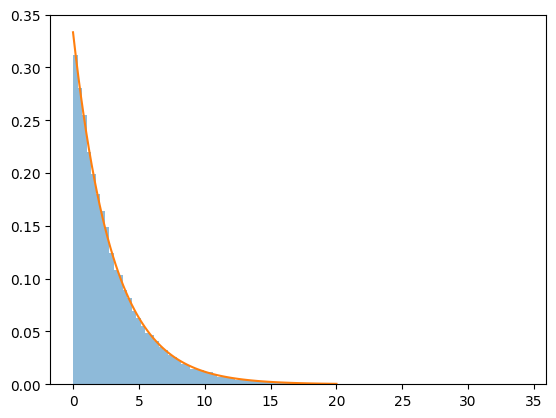

In [26]:
# Generating E[X] using integration and sampling approximation

# p(x) for exponentational function
def p(x, mean=3):
    lam = 1/mean
    return lam * np.exp(-lam * x)

e_x = quad(lambda x: x * p(x), 0, np.inf)[0]

estimated_mean = np.sum(data) / len(data)

print(f"Estimated mean: {estimated_mean}, Actual mean: {e_x}")

plt.hist(data, bins=100, density=True, alpha=0.5)
plt.plot(np.linspace(0, 20, 100), p(np.linspace(0, 20, 100)))
plt.show()


